In [ ]:
from pathlib import Path
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box, Point
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Google Drive mount check

try:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception as e:
    print(f"Drive mount skipped: {e}")

# Project paths

candidate_bases = [
    Path("/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles"),
    Path("/content/gdrive_results/MyDrive/STAT596/Project596_datafiles"),
    Path("/content/drive/MyDrive/STAT596/Project596_datafiles"),
    Path("/content/gdrive/MyDrive/STAT596/Project596_datafiles"),
]

existing_bases = [p for p in candidate_bases if p.exists()]

if existing_bases:
    BASE = existing_bases[0]
else:
    BASE = candidate_bases[0]

PROCESSED = BASE / "processed_data"
TABLES = BASE / "tables"
FIGURES = BASE / "figures"

for folder in [PROCESSED, TABLES, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("PROCESSED exists:", PROCESSED.exists())
print("TABLES exists:", TABLES.exists())
print("FIGURES exists:", FIGURES.exists())

# Expected input files

expected_inputs = {
    "notebook11_beach_station_map_summary": TABLES / "notebook11_beach_station_map_summary.csv",
    "notebook11_h2s_station_map_summary": TABLES / "notebook11_h2s_station_map_summary.csv",
    "notebook11_h2s_station_pattern_summary": TABLES / "notebook11_h2s_station_pattern_summary.csv",
    "notebook11_community_proximity_monitoring_context_summary": TABLES / "notebook11_community_proximity_monitoring_context_summary.csv",
    "daily_environmental_analysis_ready": PROCESSED / "daily_environmental_analysis_ready.csv",
    "prism_daily_rainfall_south_bay": PROCESSED / "prism_daily_rainfall_south_bay.csv",
    "tijuana_river_daily_flow_2023_2026": PROCESSED / "tijuana_river_daily_flow_2023_2026.csv",
    "beach_monitoring_stations_clean": PROCESSED / "beach_monitoring_stations_clean.csv",
}

def file_info(label, path):
    path = Path(path)

    return {
        "label": label,
        "file_name": path.name,
        "file_path": str(path),
        "exists": path.exists(),
        "file_size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else np.nan,
        "modified_time": datetime.fromtimestamp(path.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S") if path.exists() else None,
    }

input_inventory = pd.DataFrame(
    [file_info(label, path) for label, path in expected_inputs.items()]
)

display(input_inventory)

# CSV column preview

csv_previews = []

for label, path in expected_inputs.items():
    if path.exists() and path.suffix.lower() == ".csv":
        try:
            preview = pd.read_csv(path, nrows=5)

            csv_previews.append({
                "label": label,
                "rows_previewed": len(preview),
                "column_count": preview.shape[1],
                "columns": list(preview.columns),
            })

        except Exception as e:
            csv_previews.append({
                "label": label,
                "rows_previewed": 0,
                "column_count": np.nan,
                "columns": f"Could not read preview: {e}",
            })

csv_preview_df = pd.DataFrame(csv_previews)

display(csv_preview_df)

# Search for possible geometry files

geo_extensions = ["*.gpkg", "*.geojson", "*.json", "*.shp"]
search_roots = [BASE, PROCESSED, TABLES]

geo_files = []

for root in search_roots:
    if root.exists():
        for ext in geo_extensions:
            geo_files.extend(root.rglob(ext))

geo_files = sorted(set(geo_files))

tract_keywords = ["tract", "census", "tiger", "south_bay", "study_area", "community"]
river_keywords = ["river", "tijuana", "usibwc", "flowline", "stream"]

possible_tract_files = [
    p for p in geo_files
    if any(k in p.name.lower() for k in tract_keywords)
]

possible_river_files = [
    p for p in geo_files
    if any(k in p.name.lower() for k in river_keywords)
]

tract_inventory = pd.DataFrame([
    file_info("possible_tract_or_study_area_geometry", p)
    for p in possible_tract_files
])

river_inventory = pd.DataFrame([
    file_info("possible_river_geometry", p)
    for p in possible_river_files
])

display(tract_inventory)

if len(river_inventory) > 0:
    display(river_inventory)
else:
    print("No obvious river geometry file found.")

# Save initial Notebook 12 input inventory

inventory_path = TABLES / "notebook12_initial_input_inventory.csv"
input_inventory.to_csv(inventory_path, index=False)

# Final QA

print("=" * 70)
print("Notebook 12 Cell 1 QA")
print("=" * 70)

print("Expected input files found:", input_inventory["exists"].sum(), "out of", len(input_inventory))
print("Missing expected inputs:", len(input_inventory.loc[~input_inventory["exists"]]))
print("Possible tract/study-area geometry files found:", len(possible_tract_files))
print("Possible river geometry files found:", len(possible_river_files))
print("Inventory saved:", inventory_path)
print("Inventory file exists:", inventory_path.exists())

missing_inputs = input_inventory.loc[~input_inventory["exists"], ["label", "file_path"]]

if len(missing_inputs) > 0:
    display(missing_inputs)

BASE: /content/drive/MyDrive/STAT596/Project596_datafiles
PROCESSED exists: True
TABLES exists: True
FIGURES exists: True


,label,file_name,file_path,exists,file_size_kb,modified_time
0,notebook11_beach_station_map_summary,notebook11_beach_station_map_summary.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,16.84,2026-05-04 14:13:50
1,notebook11_h2s_station_map_summary,notebook11_h2s_station_map_summary.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,0.50,2026-05-04 14:13:50
2,notebook11_h2s_station_pattern_summary,notebook11_h2s_station_pattern_summary.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,0.43,2026-05-04 15:14:43
3,notebook11_community_proximity_monitoring_cont...,notebook11_community_proximity_monitoring_cont...,/content/drive/MyDrive/STAT596/Project596_data...,True,12.32,2026-05-04 15:25:42
4,daily_environmental_analysis_ready,daily_environmental_analysis_ready.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,485.57,2026-05-04 11:07:29
5,prism_daily_rainfall_south_bay,prism_daily_rainfall_south_bay.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,56.52,2026-05-03 18:57:15
6,tijuana_river_daily_flow_2023_2026,tijuana_river_daily_flow_2023_2026.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,330.91,2026-05-04 08:30:31
7,beach_monitoring_stations_clean,beach_monitoring_stations_clean.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,106.12,2026-05-04 09:46:04


,label,rows_previewed,column_count,columns
0,notebook11_beach_station_map_summary,5,16,"[station_id, station_name, station_name_clean,..."
1,notebook11_h2s_station_map_summary,3,11,"[location_clean, target_lat, target_lon, h2s_e..."
2,notebook11_h2s_station_pattern_summary,3,9,"[location_clean, full_station_name, h2s_event_..."
3,notebook11_community_proximity_monitoring_cont...,5,4,"[tract_index, dist_to_nearest_h2s_km, dist_to_..."
4,daily_environmental_analysis_ready,5,77,"[date, active_advisory_records, active_closure..."
5,prism_daily_rainfall_south_bay,5,6,"[date, rain_mm, rain_lag1_mm, rain_3day_mm, ra..."
6,tijuana_river_daily_flow_2023_2026,5,32,"[date, start_datetime, end_datetime, interval_..."
7,beach_monitoring_stations_clean,5,34,"[station_id, station_agency_id, beach_name_id,..."


,label,file_name,file_path,exists,file_size_kb,modified_time
0,possible_tract_or_study_area_geometry,Census_Tract_Tiger_2020.shp,/content/drive/MyDrive/STAT596/Project596_data...,True,3824.97,1979-11-30 08:00:00
1,possible_tract_or_study_area_geometry,notebook12_study_area_boundary.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,160.00,2026-05-04 21:02:25
2,possible_tract_or_study_area_geometry,south_bay_census_tracts_proximity.geojson,/content/drive/MyDrive/STAT596/Project596_data...,True,2764.69,2026-05-04 10:20:43
3,possible_tract_or_study_area_geometry,sd_census_tracts_clean.geojson,/content/drive/MyDrive/STAT596/Project596_data...,True,13053.15,2026-04-29 12:16:36
4,possible_tract_or_study_area_geometry,south_bay_census_tracts.geojson,/content/drive/MyDrive/STAT596/Project596_data...,True,3053.12,2026-04-29 12:16:36


No obvious river geometry file found.
Notebook 12 Cell 1 QA
Expected input files found: 8 out of 8
Missing expected inputs: 0
Possible tract/study-area geometry files found: 5
Possible river geometry files found: 0
Inventory saved: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_initial_input_inventory.csv
Inventory file exists: True


In [ ]:
from pathlib import Path
import geopandas as gpd

preferred_study_area_names = [
    "south_bay_census_tracts_proximity.geojson",
    "south_bay_census_tracts.geojson",
    "sd_census_tracts_clean.geojson",
    "Census_Tract_Tiger_2020.shp",
]

study_area_path = None

for file_name in preferred_study_area_names:
    matches = list(BASE.rglob(file_name))
    if matches:
        study_area_path = matches[0]
        break

if study_area_path is None:
    raise FileNotFoundError("No study-area geometry file found.")

tracts = gpd.read_file(study_area_path)

if tracts.crs is None:
    tracts = tracts.set_crs("EPSG:4326")

tracts = tracts[tracts.geometry.notna()].copy()
tracts = tracts[~tracts.geometry.is_empty].copy()

if (~tracts.geometry.is_valid).sum() > 0:
    tracts["geometry"] = tracts.geometry.buffer(0)

tracts_3310 = tracts.to_crs("EPSG:3310")

study_area_boundary_3310 = tracts_3310.dissolve().reset_index(drop=True)
study_area_boundary_3310["area_sq_km"] = study_area_boundary_3310.geometry.area / 1_000_000

study_area_boundary_path = PROCESSED / "notebook12_study_area_boundary.gpkg"

study_area_boundary_3310.to_file(
    study_area_boundary_path,
    layer="study_area_boundary_epsg3310",
    driver="GPKG"
)

print("Study area path:", study_area_path)
print("Original CRS:", tracts.crs)
print("Projected CRS:", study_area_boundary_3310.crs)
print("Tract rows:", len(tracts))
print("Boundary rows:", len(study_area_boundary_3310))
print("Study area sq km:", round(study_area_boundary_3310["area_sq_km"].iloc[0], 2))
print("Saved:", study_area_boundary_path)
print("File exists:", study_area_boundary_path.exists())

Study area path: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/south_bay_census_tracts_proximity.geojson
Original CRS: EPSG:4326
Projected CRS: EPSG:3310
Tract rows: 263
Boundary rows: 1
Study area sq km: 1774.06
Saved: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_study_area_boundary.gpkg
File exists: True


In [ ]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box

# Load study-area boundary

study_area_boundary_path = PROCESSED / "notebook12_study_area_boundary.gpkg"

study_area_boundary_3310 = gpd.read_file(
    study_area_boundary_path,
    layer="study_area_boundary_epsg3310"
)

study_area_boundary_3310 = study_area_boundary_3310.to_crs("EPSG:3310")

# Build 1 km grid

GRID_SIZE_M = 1000

minx, miny, maxx, maxy = study_area_boundary_3310.total_bounds

x_coords = np.arange(minx, maxx + GRID_SIZE_M, GRID_SIZE_M)
y_coords = np.arange(miny, maxy + GRID_SIZE_M, GRID_SIZE_M)

grid_records = []

for row_id, y in enumerate(y_coords[:-1]):
    for col_id, x in enumerate(x_coords[:-1]):
        grid_records.append({
            "grid_id": f"cell_{row_id:03d}_{col_id:03d}",
            "row_id": row_id,
            "col_id": col_id,
            "geometry": box(x, y, x + GRID_SIZE_M, y + GRID_SIZE_M)
        })

grid_full_3310 = gpd.GeoDataFrame(
    grid_records,
    geometry="geometry",
    crs="EPSG:3310"
)

# Clip grid to study area

study_area_geom = study_area_boundary_3310.geometry.union_all()

grid_1km_3310 = grid_full_3310[grid_full_3310.intersects(study_area_geom)].copy()
grid_1km_3310["geometry"] = grid_1km_3310.geometry.intersection(study_area_geom)

grid_1km_3310 = grid_1km_3310[grid_1km_3310.geometry.notna()].copy()
grid_1km_3310 = grid_1km_3310[~grid_1km_3310.geometry.is_empty].copy()

grid_1km_3310["cell_area_sq_km"] = grid_1km_3310.geometry.area / 1_000_000

# Add centroids

centroids_3310 = grid_1km_3310.geometry.centroid
centroids_wgs84 = gpd.GeoSeries(centroids_3310, crs="EPSG:3310").to_crs("EPSG:4326")

grid_1km_3310["centroid_x_3310"] = centroids_3310.x
grid_1km_3310["centroid_y_3310"] = centroids_3310.y
grid_1km_3310["centroid_lon"] = centroids_wgs84.x
grid_1km_3310["centroid_lat"] = centroids_wgs84.y
grid_1km_3310["grid_resolution_m"] = GRID_SIZE_M

# Save base grid

base_grid_path = PROCESSED / "notebook12_base_1km_grid.gpkg"

grid_1km_3310.to_file(
    base_grid_path,
    layer="base_grid_1km_epsg3310",
    driver="GPKG"
)

# QA

print("=" * 70)
print("Notebook 12 Cell 3 QA")
print("=" * 70)

print("Study-area CRS:", study_area_boundary_3310.crs)
print("Grid CRS:", grid_1km_3310.crs)
print("Grid resolution meters:", GRID_SIZE_M)
print("Full grid cells before clipping:", len(grid_full_3310))
print("Grid cells after clipping:", len(grid_1km_3310))
print("Minimum cell area sq km:", round(grid_1km_3310["cell_area_sq_km"].min(), 4))
print("Maximum cell area sq km:", round(grid_1km_3310["cell_area_sq_km"].max(), 4))
print("Total clipped grid area sq km:", round(grid_1km_3310["cell_area_sq_km"].sum(), 2))
print("Saved:", base_grid_path)
print("File exists:", base_grid_path.exists())

display(grid_1km_3310.head())

Notebook 12 Cell 3 QA
Study-area CRS: EPSG:3310
Grid CRS: EPSG:3310
Grid resolution meters: 1000
Full grid cells before clipping: 8554
Grid cells after clipping: 1986
Minimum cell area sq km: 0.0
Maximum cell area sq km: 1.0
Total clipped grid area sq km: 1774.06
Saved: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_base_1km_grid.gpkg
File exists: True


,grid_id,row_id,col_id,geometry,cell_area_sq_km,centroid_x_3310,centroid_y_3310,centroid_lon,centroid_lat,grid_resolution_m
40,cell_000_040,0,40,"POLYGON ((263536.953 -604327.048, 263536.953 -...",0.628112,263208.236961,-604787.981905,-117.202447,32.533641,1000
41,cell_000_041,0,41,"POLYGON ((263536.953 -604327.048, 264536.953 -...",0.883062,264026.395981,-604769.169809,-117.193750,32.533593,1000
42,cell_000_042,0,42,"POLYGON ((264536.953 -604327.048, 265536.953 -...",0.770947,265024.813113,-604713.203647,-117.183127,32.533831,1000
43,cell_000_043,0,43,"POLYGON ((265536.953 -604327.048, 266536.953 -...",0.658638,266022.743071,-604657.165213,-117.172509,32.534068,1000
44,cell_000_044,0,44,"POLYGON ((266536.953 -604327.048, 267536.953 -...",0.546329,267019.821949,-604601.174571,-117.161899,32.534305,1000


In [ ]:
# Clean clipped grid

base_grid_path = PROCESSED / "notebook12_base_1km_grid.gpkg"

grid_1km_3310 = gpd.read_file(
    base_grid_path,
    layer="base_grid_1km_epsg3310"
)

grid_1km_3310 = grid_1km_3310.to_crs("EPSG:3310")
grid_1km_3310["cell_area_sq_km"] = grid_1km_3310.geometry.area / 1_000_000

MIN_CELL_AREA_SQ_KM = 0.01

grid_1km_clean_3310 = grid_1km_3310[
    grid_1km_3310["cell_area_sq_km"] >= MIN_CELL_AREA_SQ_KM
].copy()

grid_1km_clean_3310 = grid_1km_clean_3310.reset_index(drop=True)
grid_1km_clean_3310["grid_id"] = [
    f"grid_{i:04d}" for i in range(len(grid_1km_clean_3310))
]

centroids_3310 = grid_1km_clean_3310.geometry.centroid
centroids_wgs84 = gpd.GeoSeries(centroids_3310, crs="EPSG:3310").to_crs("EPSG:4326")

grid_1km_clean_3310["centroid_x_3310"] = centroids_3310.x
grid_1km_clean_3310["centroid_y_3310"] = centroids_3310.y
grid_1km_clean_3310["centroid_lon"] = centroids_wgs84.x
grid_1km_clean_3310["centroid_lat"] = centroids_wgs84.y
grid_1km_clean_3310["grid_resolution_m"] = 1000

clean_grid_path = PROCESSED / "notebook12_clean_1km_grid.gpkg"

grid_1km_clean_3310.to_file(
    clean_grid_path,
    layer="clean_grid_1km_epsg3310",
    driver="GPKG"
)

print("=" * 70)
print("Notebook 12 Cell 3B QA")
print("=" * 70)

print("Original clipped grid cells:", len(grid_1km_3310))
print("Clean grid cells:", len(grid_1km_clean_3310))
print("Removed cells:", len(grid_1km_3310) - len(grid_1km_clean_3310))
print("Minimum retained cell area sq km:", round(grid_1km_clean_3310["cell_area_sq_km"].min(), 4))
print("Maximum retained cell area sq km:", round(grid_1km_clean_3310["cell_area_sq_km"].max(), 4))
print("Total retained grid area sq km:", round(grid_1km_clean_3310["cell_area_sq_km"].sum(), 2))
print("Saved:", clean_grid_path)
print("File exists:", clean_grid_path.exists())

display(grid_1km_clean_3310.head())

Notebook 12 Cell 3B QA
Original clipped grid cells: 1986
Clean grid cells: 1963
Removed cells: 23
Minimum retained cell area sq km: 0.0101
Maximum retained cell area sq km: 1.0
Total retained grid area sq km: 1773.97
Saved: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_clean_1km_grid.gpkg
File exists: True


,grid_id,row_id,col_id,cell_area_sq_km,centroid_x_3310,centroid_y_3310,centroid_lon,centroid_lat,grid_resolution_m,geometry
0,grid_0000,0,40,0.628112,263208.236961,-604787.981905,-117.202447,32.533641,1000,"MULTIPOLYGON (((263536.953 -604327.048, 263536..."
1,grid_0001,0,41,0.883062,264026.395981,-604769.169809,-117.193750,32.533593,1000,"MULTIPOLYGON (((263536.953 -604327.048, 264536..."
2,grid_0002,0,42,0.770947,265024.813113,-604713.203647,-117.183127,32.533831,1000,"MULTIPOLYGON (((264536.953 -604327.048, 265536..."
3,grid_0003,0,43,0.658638,266022.743071,-604657.165213,-117.172509,32.534068,1000,"MULTIPOLYGON (((265536.953 -604327.048, 266536..."
4,grid_0004,0,44,0.546329,267019.821949,-604601.174571,-117.161899,32.534305,1000,"MULTIPOLYGON (((266536.953 -604327.048, 267536..."


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Input files

beach_summary_path = TABLES / "notebook11_beach_station_map_summary.csv"
h2s_map_path = TABLES / "notebook11_h2s_station_map_summary.csv"
h2s_pattern_path = TABLES / "notebook11_h2s_station_pattern_summary.csv"

beach_df = pd.read_csv(beach_summary_path)
h2s_map_df = pd.read_csv(h2s_map_path)
h2s_pattern_df = pd.read_csv(h2s_pattern_path)

# Helper functions

def find_column(df, candidates):
    lower_lookup = {col.lower(): col for col in df.columns}

    for candidate in candidates:
        if candidate.lower() in lower_lookup:
            return lower_lookup[candidate.lower()]

    return None

def find_column_by_keywords(df, required_keywords):
    for col in df.columns:
        col_lower = col.lower()
        if all(keyword in col_lower for keyword in required_keywords):
            return col

    return None

# Beach coordinate and intensity columns

beach_lat_col = find_column(
    beach_df,
    ["station_lat", "target_lat", "lat", "latitude", "beach_lat"]
)

beach_lon_col = find_column(
    beach_df,
    ["station_lon", "target_lon", "lon", "longitude", "beach_lon"]
)

beach_closure_col = find_column(
    beach_df,
    [
        "active_closure_record_days",
        "closure_active_record_days",
        "total_active_closure_record_days",
        "active_closure_days",
        "closure_record_days",
        "closure_days",
    ]
)

if beach_closure_col is None:
    beach_closure_col = find_column_by_keywords(beach_df, ["closure", "day"])

if beach_lat_col is None or beach_lon_col is None:
    raise ValueError("Beach latitude/longitude columns were not found.")

beach_df[beach_lat_col] = pd.to_numeric(beach_df[beach_lat_col], errors="coerce")
beach_df[beach_lon_col] = pd.to_numeric(beach_df[beach_lon_col], errors="coerce")

if beach_closure_col is not None:
    beach_df[beach_closure_col] = pd.to_numeric(beach_df[beach_closure_col], errors="coerce")

beach_points_df = beach_df.dropna(subset=[beach_lat_col, beach_lon_col]).copy()

beach_gdf_wgs84 = gpd.GeoDataFrame(
    beach_points_df,
    geometry=gpd.points_from_xy(beach_points_df[beach_lon_col], beach_points_df[beach_lat_col]),
    crs="EPSG:4326"
)

beach_gdf_3310 = beach_gdf_wgs84.to_crs("EPSG:3310")

if beach_closure_col is not None:
    top_closure_beach_gdf_3310 = beach_gdf_3310.sort_values(
        beach_closure_col,
        ascending=False
    ).head(10).copy()
else:
    top_closure_beach_gdf_3310 = beach_gdf_3310.head(10).copy()

# H2S coordinate and severity columns

h2s_df = h2s_map_df.merge(
    h2s_pattern_df,
    on="location_clean",
    how="left",
    suffixes=("", "_pattern")
)

h2s_lat_col = find_column(
    h2s_df,
    ["target_lat", "station_lat", "lat", "latitude"]
)

h2s_lon_col = find_column(
    h2s_df,
    ["target_lon", "station_lon", "lon", "longitude"]
)

h2s_max_col = find_column(
    h2s_df,
    ["max_h2s_ppb", "h2s_max_ppb", "maximum_h2s_ppb"]
)

if h2s_max_col is None:
    h2s_max_col = find_column_by_keywords(h2s_df, ["max", "h2s"])

h2s_event30_col = find_column(
    h2s_df,
    [
        "h2s_events_ge_30_ppb",
        "h2s_event_count_ge_30_ppb",
        "orange_h2s_event_count",
        "orange_event_count",
    ]
)

if h2s_event30_col is None:
    h2s_event30_col = find_column_by_keywords(h2s_df, ["30"])

if h2s_lat_col is None or h2s_lon_col is None:
    raise ValueError("H2S latitude/longitude columns were not found.")

h2s_df[h2s_lat_col] = pd.to_numeric(h2s_df[h2s_lat_col], errors="coerce")
h2s_df[h2s_lon_col] = pd.to_numeric(h2s_df[h2s_lon_col], errors="coerce")

if h2s_max_col is not None:
    h2s_df[h2s_max_col] = pd.to_numeric(h2s_df[h2s_max_col], errors="coerce")

if h2s_event30_col is not None:
    h2s_df[h2s_event30_col] = pd.to_numeric(h2s_df[h2s_event30_col], errors="coerce")

h2s_points_df = h2s_df.dropna(subset=[h2s_lat_col, h2s_lon_col]).copy()

h2s_gdf_wgs84 = gpd.GeoDataFrame(
    h2s_points_df,
    geometry=gpd.points_from_xy(h2s_points_df[h2s_lon_col], h2s_points_df[h2s_lat_col]),
    crs="EPSG:4326"
)

h2s_gdf_3310 = h2s_gdf_wgs84.to_crs("EPSG:3310")

# Save point layers

context_points_path = PROCESSED / "notebook12_monitoring_context_points.gpkg"

if context_points_path.exists():
    context_points_path.unlink()

beach_gdf_3310.to_file(
    context_points_path,
    layer="beach_stations_epsg3310",
    driver="GPKG"
)

top_closure_beach_gdf_3310.to_file(
    context_points_path,
    layer="top_closure_beach_stations_epsg3310",
    driver="GPKG"
)

h2s_gdf_3310.to_file(
    context_points_path,
    layer="h2s_stations_epsg3310",
    driver="GPKG"
)

# QA



print("Beach rows loaded:", len(beach_df))
print("Beach point rows:", len(beach_gdf_3310))
print("Beach latitude column:", beach_lat_col)
print("Beach longitude column:", beach_lon_col)
print("Beach closure column:", beach_closure_col)
print("Beach CRS:", beach_gdf_3310.crs)

print("H2S rows loaded:", len(h2s_df))
print("H2S point rows:", len(h2s_gdf_3310))
print("H2S latitude column:", h2s_lat_col)
print("H2S longitude column:", h2s_lon_col)
print("H2S max column:", h2s_max_col)
print("H2S >= 30 ppb column:", h2s_event30_col)
print("H2S CRS:", h2s_gdf_3310.crs)

print("Saved:", context_points_path)
print("File exists:", context_points_path.exists())

if beach_closure_col is not None:
    display(
        top_closure_beach_gdf_3310[
            [col for col in ["station_id", "station_name", "station_name_clean", beach_closure_col] if col in top_closure_beach_gdf_3310.columns]
        ].head(10)
    )

display(
    h2s_gdf_3310[
        [col for col in ["location_clean", h2s_max_col, h2s_event30_col] if col in h2s_gdf_3310.columns and col is not None]
    ]
)

Notebook 12 Cell 4 QA
Beach rows loaded: 134
Beach point rows: 134
Beach latitude column: station_lat
Beach longitude column: station_lon
Beach closure column: active_closure_record_days
Beach CRS: EPSG:3310
H2S rows loaded: 3
H2S point rows: 3
H2S latitude column: target_lat
H2S longitude column: target_lon
H2S max column: max_h2s_ppb
H2S >= 30 ppb column: orange_h2s_event_count
H2S CRS: EPSG:3310
Saved: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_monitoring_context_points.gpkg
File exists: True


,station_id,station_name,station_name_clean,active_closure_record_days
55,455,IB-010,IB-010,1159
57,459,IB-050,IB-050,1081
61,461,IB-070,IB-070,817
2,319,EH-010,EH-010,484
4,322,EH-030,EH-030,480
59,460,IB-060,IB-060,473
111,1038,IB-079,IB-079,455
6,325,EH-050,EH-050,372
8,328,EH-060,EH-060,353
63,462,IB-080,IB-080,103


,location_clean,max_h2s_ppb,orange_h2s_event_count
0,IB CIVIC CTR,27.9,0
1,NESTOR - BES,295.6,7
2,SAN YSIDRO,45.5,4


In [ ]:
# no scores yet. Only adding distance fields to each 1 km grid cell.

import numpy as np
import pandas as pd
import geopandas as gpd

# Input files

clean_grid_path = PROCESSED / "notebook12_clean_1km_grid.gpkg"
context_points_path = PROCESSED / "notebook12_monitoring_context_points.gpkg"

grid_1km_3310 = gpd.read_file(
    clean_grid_path,
    layer="clean_grid_1km_epsg3310"
).to_crs("EPSG:3310")

beach_gdf_3310 = gpd.read_file(
    context_points_path,
    layer="beach_stations_epsg3310"
).to_crs("EPSG:3310")

top_closure_beach_gdf_3310 = gpd.read_file(
    context_points_path,
    layer="top_closure_beach_stations_epsg3310"
).to_crs("EPSG:3310")

h2s_gdf_3310 = gpd.read_file(
    context_points_path,
    layer="h2s_stations_epsg3310"
).to_crs("EPSG:3310")

# Helper functions

def nearest_distance_km(source_gdf, target_gdf):
    if len(target_gdf) == 0:
        return pd.Series(np.nan, index=source_gdf.index)

    target_union = target_gdf.geometry.union_all()
    return source_gdf.geometry.centroid.distance(target_union) / 1000

def identify_impacted_beaches(beach_gdf):
    impact_mask = pd.Series(False, index=beach_gdf.index)

    possible_group_cols = [
        "study_group",
        "beach_group",
        "analysis_group",
        "impact_group",
        "group"
    ]

    for col in possible_group_cols:
        if col in beach_gdf.columns:
            values = beach_gdf[col].astype(str).str.lower()
            impact_mask = impact_mask | values.str.contains(
                "south bay|tijuana|impact|river",
                regex=True,
                na=False
            )

    return beach_gdf.loc[impact_mask].copy()

# Distance variables

impacted_beach_gdf_3310 = identify_impacted_beaches(beach_gdf_3310)

grid_distance_3310 = grid_1km_3310.copy()

grid_distance_3310["dist_to_nearest_h2s_station_km"] = nearest_distance_km(
    grid_distance_3310,
    h2s_gdf_3310
)

grid_distance_3310["dist_to_nearest_beach_station_km"] = nearest_distance_km(
    grid_distance_3310,
    beach_gdf_3310
)

grid_distance_3310["dist_to_nearest_top_closure_beach_km"] = nearest_distance_km(
    grid_distance_3310,
    top_closure_beach_gdf_3310
)

if len(impacted_beach_gdf_3310) > 0:
    grid_distance_3310["dist_to_nearest_impacted_beach_km"] = nearest_distance_km(
        grid_distance_3310,
        impacted_beach_gdf_3310
    )
else:
    grid_distance_3310["dist_to_nearest_impacted_beach_km"] = np.nan

grid_distance_3310["river_distance_available"] = False
grid_distance_3310["dist_to_tijuana_river_km"] = np.nan

# Save outputs

distance_grid_path = PROCESSED / "notebook12_grid_distance_variables.gpkg"

grid_distance_3310.to_file(
    distance_grid_path,
    layer="grid_distance_variables_epsg3310",
    driver="GPKG"
)

distance_cols = [
    "dist_to_nearest_h2s_station_km",
    "dist_to_nearest_beach_station_km",
    "dist_to_nearest_top_closure_beach_km",
    "dist_to_nearest_impacted_beach_km",
    "dist_to_tijuana_river_km"
]

distance_summary = (
    grid_distance_3310[distance_cols]
    .agg(["count", "min", "median", "mean", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "distance_variable"})
)

distance_summary_path = TABLES / "notebook12_distance_variable_summary.csv"
distance_summary.to_csv(distance_summary_path, index=False)

# QA



print("Grid rows:", len(grid_distance_3310))
print("Beach station rows:", len(beach_gdf_3310))
print("Top closure beach station rows:", len(top_closure_beach_gdf_3310))
print("Impacted beach station rows identified:", len(impacted_beach_gdf_3310))
print("H2S station rows:", len(h2s_gdf_3310))
print("River distance available:", grid_distance_3310["river_distance_available"].iloc[0])
print("Saved grid:", distance_grid_path)
print("Grid file exists:", distance_grid_path.exists())
print("Saved summary:", distance_summary_path)
print("Summary file exists:", distance_summary_path.exists())

display(distance_summary)

display(
    grid_distance_3310[
        [
            "grid_id",
            "cell_area_sq_km",
            "dist_to_nearest_h2s_station_km",
            "dist_to_nearest_beach_station_km",
            "dist_to_nearest_top_closure_beach_km",
            "dist_to_nearest_impacted_beach_km",
            "dist_to_tijuana_river_km"
        ]
    ].head()
)

Notebook 12 Cell 5 QA
Grid rows: 1963
Beach station rows: 134
Top closure beach station rows: 10
Impacted beach station rows identified: 26
H2S station rows: 3
River distance available: False
Saved grid: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_grid_distance_variables.gpkg
Grid file exists: True
Saved summary: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_distance_variable_summary.csv
Summary file exists: True


,distance_variable,count,min,median,mean,max
0,dist_to_nearest_h2s_station_km,1963.0,0.409142,22.967447,29.898246,98.931525
1,dist_to_nearest_beach_station_km,1963.0,0.072040,7.031360,12.744511,42.407568
2,dist_to_nearest_top_closure_beach_km,1963.0,0.072040,22.730752,26.436868,85.523536
3,dist_to_nearest_impacted_beach_km,1963.0,0.072040,22.443697,26.004195,84.982744
4,dist_to_tijuana_river_km,0.0,NaN,NaN,NaN,NaN


,grid_id,cell_area_sq_km,dist_to_nearest_h2s_station_km,dist_to_nearest_beach_station_km,dist_to_nearest_top_closure_beach_km,dist_to_nearest_impacted_beach_km,dist_to_tijuana_river_km
0,grid_0000,0.628112,10.122812,7.357862,7.357862,7.357862,NaN
1,grid_0001,0.883062,9.457771,6.540286,6.540286,6.540286,NaN
2,grid_0002,0.770947,8.659566,5.540416,5.540416,5.540416,NaN
3,grid_0003,0.658638,7.907663,4.541075,4.541075,4.541075,NaN
4,grid_0004,0.546329,7.216665,3.542678,3.542678,3.542678,NaN


In [ ]:
import geopandas as gpd

# River geometry

river_url = (
    "https://services.arcgis.com/o6oETlrWetREI1A2/arcgis/rest/services/"
    "San_Diego_County_and_Tijuana_Rivers_New/FeatureServer/0/query?"
    "where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson"
)

rivers = gpd.read_file(river_url)

tijuana_river = rivers[
    rivers["NAME"]
    .astype(str)
    .str.contains("Tijuana|Rio Tijuana|Río Tijuana", case=False, na=False)
].copy()

if len(tijuana_river) == 0:
    raise ValueError("No Tijuana River geometry was found.")

tijuana_river = tijuana_river.to_crs("EPSG:3310")

# Save river geometry

river_geometry_path = PROCESSED / "notebook12_tijuana_river_geometry.gpkg"

if river_geometry_path.exists():
    river_geometry_path.unlink()

tijuana_river.to_file(
    river_geometry_path,
    layer="tijuana_river_epsg3310",
    driver="GPKG"
)

# Update distance grid

distance_grid_path = PROCESSED / "notebook12_grid_distance_variables.gpkg"

grid_distance_3310 = gpd.read_file(
    distance_grid_path,
    layer="grid_distance_variables_epsg3310"
).to_crs("EPSG:3310")

river_union = tijuana_river.geometry.union_all()

grid_distance_3310["river_distance_available"] = True
grid_distance_3310["dist_to_tijuana_river_km"] = (
    grid_distance_3310.geometry.centroid.distance(river_union) / 1000
)

if distance_grid_path.exists():
    distance_grid_path.unlink()

grid_distance_3310.to_file(
    distance_grid_path,
    layer="grid_distance_variables_epsg3310",
    driver="GPKG"
)

# Distance summary

distance_cols = [
    "dist_to_nearest_h2s_station_km",
    "dist_to_nearest_beach_station_km",
    "dist_to_nearest_top_closure_beach_km",
    "dist_to_nearest_impacted_beach_km",
    "dist_to_tijuana_river_km",
]

distance_summary = (
    grid_distance_3310[distance_cols]
    .agg(["count", "min", "median", "mean", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "distance_variable"})
)

distance_summary_path = TABLES / "notebook12_distance_variable_summary.csv"
distance_summary.to_csv(distance_summary_path, index=False)

# QA



print("Total river rows loaded:", len(rivers))
print("Tijuana River rows:", len(tijuana_river))
print("River CRS:", tijuana_river.crs)
print("River geometry types:", tijuana_river.geometry.geom_type.value_counts().to_dict())
print("River length km:", round(tijuana_river.geometry.length.sum() / 1000, 2))
print("Grid rows updated:", len(grid_distance_3310))
print("River distance available:", grid_distance_3310["river_distance_available"].iloc[0])
print("Minimum river distance km:", round(grid_distance_3310["dist_to_tijuana_river_km"].min(), 4))
print("Median river distance km:", round(grid_distance_3310["dist_to_tijuana_river_km"].median(), 4))
print("Maximum river distance km:", round(grid_distance_3310["dist_to_tijuana_river_km"].max(), 4))
print("Saved river geometry:", river_geometry_path)
print("River file exists:", river_geometry_path.exists())
print("Updated distance grid:", distance_grid_path)
print("Distance grid exists:", distance_grid_path.exists())
print("Updated summary:", distance_summary_path)
print("Summary exists:", distance_summary_path.exists())

display(distance_summary)
display(tijuana_river.head())

Notebook 12 Cell 5B QA
Total river rows loaded: 518
Tijuana River rows: 1
River CRS: EPSG:3310
River geometry types: {'LineString': 1}
River length km: 1.27
Grid rows updated: 1963
River distance available: True
Minimum river distance km: 0.0338
Median river distance km: 32.1915
Maximum river distance km: 117.9712
Saved river geometry: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_tijuana_river_geometry.gpkg
River file exists: True
Updated distance grid: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_grid_distance_variables.gpkg
Distance grid exists: True
Updated summary: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_distance_variable_summary.csv
Summary exists: True


,distance_variable,count,min,median,mean,max
0,dist_to_nearest_h2s_station_km,1963.0,0.409142,22.967447,29.898246,98.931525
1,dist_to_nearest_beach_station_km,1963.0,0.072040,7.031360,12.744511,42.407568
2,dist_to_nearest_top_closure_beach_km,1963.0,0.072040,22.730752,26.436868,85.523536
3,dist_to_nearest_impacted_beach_km,1963.0,0.072040,22.443697,26.004195,84.982744
4,dist_to_tijuana_river_km,1963.0,0.033841,32.191480,40.732088,117.971165


,OBJECTID_1,NAME,CLASS,OBJECTID,SHP_ID_LEN,Id,Shape__Length,geometry
504,505,TIJUANA RIVER,MAJOR,356.0,10032.821936,NaN,1504.498824,"LINESTRING (302967.549 -599737.008, 302995.488..."


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

# Input files

distance_grid_path = PROCESSED / "notebook12_grid_distance_variables.gpkg"
context_points_path = PROCESSED / "notebook12_monitoring_context_points.gpkg"

grid_distance_3310 = gpd.read_file(
    distance_grid_path,
    layer="grid_distance_variables_epsg3310"
).to_crs("EPSG:3310")

beach_gdf_3310 = gpd.read_file(
    context_points_path,
    layer="beach_stations_epsg3310"
).to_crs("EPSG:3310")

top_closure_beach_gdf_3310 = gpd.read_file(
    context_points_path,
    layer="top_closure_beach_stations_epsg3310"
).to_crs("EPSG:3310")

h2s_gdf_3310 = gpd.read_file(
    context_points_path,
    layer="h2s_stations_epsg3310"
).to_crs("EPSG:3310")

# Helper functions

def find_column(df, candidates):
    lower_lookup = {col.lower(): col for col in df.columns}

    for candidate in candidates:
        if candidate.lower() in lower_lookup:
            return lower_lookup[candidate.lower()]

    return None

def find_column_by_keywords(df, required_keywords):
    for col in df.columns:
        col_lower = col.lower()

        if all(keyword in col_lower for keyword in required_keywords):
            return col

    return None

def nearby_weighted_sum(grid_gdf, point_gdf, value_col, radius_km=5):
    radius_m = radius_km * 1000
    grid_centroids = grid_gdf.geometry.centroid
    point_geoms = list(point_gdf.geometry)
    point_values = pd.to_numeric(point_gdf[value_col], errors="coerce").fillna(0).to_numpy()

    results = []

    for centroid in grid_centroids:
        distances_m = np.array([centroid.distance(point) for point in point_geoms])
        within_radius = distances_m <= radius_m

        if within_radius.sum() == 0:
            results.append(0)
            continue

        distances_within = distances_m[within_radius]
        values_within = point_values[within_radius]

        weights = 1 - (distances_within / radius_m)
        weighted_sum = np.sum(values_within * weights)

        results.append(weighted_sum)

    return pd.Series(results, index=grid_gdf.index)

def nearby_point_count(grid_gdf, point_gdf, radius_km=5):
    radius_m = radius_km * 1000
    grid_centroids = grid_gdf.geometry.centroid
    point_geoms = list(point_gdf.geometry)

    results = []

    for centroid in grid_centroids:
        distances_m = np.array([centroid.distance(point) for point in point_geoms])
        results.append(int((distances_m <= radius_m).sum()))

    return pd.Series(results, index=grid_gdf.index)

# Identify columns

beach_closure_col = find_column(
    beach_gdf_3310,
    [
        "active_closure_record_days",
        "closure_active_record_days",
        "total_active_closure_record_days",
        "active_closure_days",
        "closure_record_days",
        "closure_days",
    ]
)

if beach_closure_col is None:
    beach_closure_col = find_column_by_keywords(beach_gdf_3310, ["closure", "day"])

h2s_max_col = find_column(
    h2s_gdf_3310,
    ["max_h2s_ppb", "h2s_max_ppb", "maximum_h2s_ppb"]
)

if h2s_max_col is None:
    h2s_max_col = find_column_by_keywords(h2s_gdf_3310, ["max", "h2s"])

h2s_event30_col = find_column(
    h2s_gdf_3310,
    [
        "orange_h2s_event_count",
        "h2s_events_ge_30_ppb",
        "h2s_event_count_ge_30_ppb",
        "orange_event_count",
    ]
)

if h2s_event30_col is None:
    h2s_event30_col = find_column_by_keywords(h2s_gdf_3310, ["30"])

if beach_closure_col is None:
    raise ValueError("Beach closure intensity column was not found.")

if h2s_max_col is None:
    raise ValueError("H2S max ppb column was not found.")

if h2s_event30_col is None:
    raise ValueError("H2S orange event count column was not found.")

# Nearby intensity variables

RADIUS_KM = 5

grid_intensity_3310 = grid_distance_3310.copy()

grid_intensity_3310["nearby_beach_station_count_5km"] = nearby_point_count(
    grid_intensity_3310,
    beach_gdf_3310,
    radius_km=RADIUS_KM
)

grid_intensity_3310["nearby_h2s_station_count_5km"] = nearby_point_count(
    grid_intensity_3310,
    h2s_gdf_3310,
    radius_km=RADIUS_KM
)

grid_intensity_3310["nearby_beach_closure_intensity_5km"] = nearby_weighted_sum(
    grid_intensity_3310,
    beach_gdf_3310,
    beach_closure_col,
    radius_km=RADIUS_KM
)

grid_intensity_3310["nearby_top_closure_beach_intensity_5km"] = nearby_weighted_sum(
    grid_intensity_3310,
    top_closure_beach_gdf_3310,
    beach_closure_col,
    radius_km=RADIUS_KM
)

grid_intensity_3310["nearby_h2s_max_ppb_intensity_5km"] = nearby_weighted_sum(
    grid_intensity_3310,
    h2s_gdf_3310,
    h2s_max_col,
    radius_km=RADIUS_KM
)

grid_intensity_3310["nearby_h2s_orange_event_intensity_5km"] = nearby_weighted_sum(
    grid_intensity_3310,
    h2s_gdf_3310,
    h2s_event30_col,
    radius_km=RADIUS_KM
)

# Save outputs

intensity_grid_path = PROCESSED / "notebook12_grid_intensity_variables.gpkg"

if intensity_grid_path.exists():
    intensity_grid_path.unlink()

grid_intensity_3310.to_file(
    intensity_grid_path,
    layer="grid_intensity_variables_epsg3310",
    driver="GPKG"
)

intensity_cols = [
    "nearby_beach_station_count_5km",
    "nearby_h2s_station_count_5km",
    "nearby_beach_closure_intensity_5km",
    "nearby_top_closure_beach_intensity_5km",
    "nearby_h2s_max_ppb_intensity_5km",
    "nearby_h2s_orange_event_intensity_5km",
]

intensity_summary = (
    grid_intensity_3310[intensity_cols]
    .agg(["count", "min", "median", "mean", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "intensity_variable"})
)

intensity_summary_path = TABLES / "notebook12_intensity_variable_summary.csv"
intensity_summary.to_csv(intensity_summary_path, index=False)



print("Grid rows:", len(grid_intensity_3310))
print("Search radius km:", RADIUS_KM)
print("River distance available:", grid_intensity_3310["river_distance_available"].iloc[0])
print("River distance nonmissing:", grid_intensity_3310["dist_to_tijuana_river_km"].notna().sum())
print("Beach closure column:", beach_closure_col)
print("H2S max column:", h2s_max_col)
print("H2S orange event column:", h2s_event30_col)
print("Saved grid:", intensity_grid_path)
print("Grid file exists:", intensity_grid_path.exists())
print("Saved summary:", intensity_summary_path)
print("Summary file exists:", intensity_summary_path.exists())

display(intensity_summary)

display(
    grid_intensity_3310[
        [
            "grid_id",
            "dist_to_tijuana_river_km",
            "nearby_beach_station_count_5km",
            "nearby_h2s_station_count_5km",
            "nearby_beach_closure_intensity_5km",
            "nearby_top_closure_beach_intensity_5km",
            "nearby_h2s_max_ppb_intensity_5km",
            "nearby_h2s_orange_event_intensity_5km",
        ]
    ].head()
)

Notebook 12 Cell 6 QA
Grid rows: 1963
Search radius km: 5
River distance available: True
River distance nonmissing: 1963
Beach closure column: active_closure_record_days
H2S max column: max_h2s_ppb
H2S orange event column: orange_h2s_event_count
Saved grid: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_grid_intensity_variables.gpkg
Grid file exists: True
Saved summary: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_intensity_variable_summary.csv
Summary file exists: True


,intensity_variable,count,min,median,mean,max
0,nearby_beach_station_count_5km,1963.0,0.0,0.0,3.558329,39.000000
1,nearby_h2s_station_count_5km,1963.0,0.0,0.0,0.109017,3.000000
2,nearby_beach_closure_intensity_5km,1963.0,0.0,0.0,73.777702,2376.103749
3,nearby_top_closure_beach_intensity_5km,1963.0,0.0,0.0,71.606797,2376.103749
4,nearby_h2s_max_ppb_intensity_5km,1963.0,0.0,0.0,4.829404,276.292189
5,nearby_h2s_orange_event_intensity_5km,1963.0,0.0,0.0,0.137130,6.297287


,grid_id,dist_to_tijuana_river_km,nearby_beach_station_count_5km,nearby_h2s_station_count_5km,nearby_beach_closure_intensity_5km,nearby_top_closure_beach_intensity_5km,nearby_h2s_max_ppb_intensity_5km,nearby_h2s_orange_event_intensity_5km
0,grid_0000,40.078862,0,0,0.000000,0.000000,0.0,0.0
1,grid_0001,39.264947,0,0,0.000000,0.000000,0.0,0.0
2,grid_0002,38.267659,0,0,0.000000,0.000000,0.0,0.0
3,grid_0003,37.270989,1,0,106.378757,106.378757,0.0,0.0
4,grid_0004,36.275325,3,0,450.628469,450.628469,0.0,0.0


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

# Input file

intensity_grid_path = PROCESSED / "notebook12_grid_intensity_variables.gpkg"

grid_intensity_3310 = gpd.read_file(
    intensity_grid_path,
    layer="grid_intensity_variables_epsg3310"
).to_crs("EPSG:3310")

# Scoring functions

def clipped_inverse_distance_score(series, clip_km=10):
    values = pd.to_numeric(series, errors="coerce")
    score = 1 - (values / clip_km)
    score = score.clip(lower=0, upper=1)
    return score

def robust_minmax_score(series, upper_quantile=0.95):
    values = pd.to_numeric(series, errors="coerce").fillna(0)
    upper = values.quantile(upper_quantile)

    if upper <= 0:
        upper = values.max()

    if upper <= 0:
        return pd.Series(0, index=values.index)

    score = values.clip(lower=0, upper=upper) / upper
    score = score.clip(lower=0, upper=1)

    return score

# Component scores

grid_scores_3310 = grid_intensity_3310.copy()

DISTANCE_CLIP_KM = 10

grid_scores_3310["h2s_proximity_score"] = clipped_inverse_distance_score(
    grid_scores_3310["dist_to_nearest_h2s_station_km"],
    clip_km=DISTANCE_CLIP_KM
)

grid_scores_3310["river_proximity_score"] = clipped_inverse_distance_score(
    grid_scores_3310["dist_to_tijuana_river_km"],
    clip_km=DISTANCE_CLIP_KM
)

grid_scores_3310["impacted_beach_proximity_score"] = clipped_inverse_distance_score(
    grid_scores_3310["dist_to_nearest_impacted_beach_km"],
    clip_km=DISTANCE_CLIP_KM
)

grid_scores_3310["top_closure_beach_proximity_score"] = clipped_inverse_distance_score(
    grid_scores_3310["dist_to_nearest_top_closure_beach_km"],
    clip_km=DISTANCE_CLIP_KM
)

grid_scores_3310["beach_closure_intensity_score"] = robust_minmax_score(
    grid_scores_3310["nearby_beach_closure_intensity_5km"],
    upper_quantile=0.95
)

grid_scores_3310["h2s_max_ppb_intensity_score"] = robust_minmax_score(
    grid_scores_3310["nearby_h2s_max_ppb_intensity_5km"],
    upper_quantile=0.95
)

grid_scores_3310["h2s_orange_event_intensity_score"] = robust_minmax_score(
    grid_scores_3310["nearby_h2s_orange_event_intensity_5km"],
    upper_quantile=0.95
)

grid_scores_3310["h2s_severity_score"] = grid_scores_3310[
    [
        "h2s_max_ppb_intensity_score",
        "h2s_orange_event_intensity_score"
    ]
].mean(axis=1)

# Weighted score

component_weights = {
    "h2s_proximity_score": 1 / 6,
    "river_proximity_score": 1 / 6,
    "impacted_beach_proximity_score": 1 / 6,
    "top_closure_beach_proximity_score": 1 / 6,
    "beach_closure_intensity_score": 1 / 6,
    "h2s_severity_score": 1 / 6,
}

score_components = list(component_weights.keys())
weight_sum = sum(component_weights.values())

grid_scores_3310["monitoring_priority_score"] = 0

for component, weight in component_weights.items():
    grid_scores_3310["monitoring_priority_score"] += (
        grid_scores_3310[component].fillna(0) * weight
    )

grid_scores_3310["monitoring_priority_score"] = (
    grid_scores_3310["monitoring_priority_score"] / weight_sum
)

# Summary tables

source_lookup = {
    "h2s_proximity_score": "dist_to_nearest_h2s_station_km",
    "river_proximity_score": "dist_to_tijuana_river_km",
    "impacted_beach_proximity_score": "dist_to_nearest_impacted_beach_km",
    "top_closure_beach_proximity_score": "dist_to_nearest_top_closure_beach_km",
    "beach_closure_intensity_score": "nearby_beach_closure_intensity_5km",
    "h2s_severity_score": "nearby_h2s_max_ppb_intensity_5km + nearby_h2s_orange_event_intensity_5km",
}

method_lookup = {
    "h2s_proximity_score": f"Clipped inverse distance, 0 to {DISTANCE_CLIP_KM} km",
    "river_proximity_score": f"Clipped inverse distance, 0 to {DISTANCE_CLIP_KM} km",
    "impacted_beach_proximity_score": f"Clipped inverse distance, 0 to {DISTANCE_CLIP_KM} km",
    "top_closure_beach_proximity_score": f"Clipped inverse distance, 0 to {DISTANCE_CLIP_KM} km",
    "beach_closure_intensity_score": "Robust min-max scaling using 95th percentile cap",
    "h2s_severity_score": "Average of robust-scaled H2S max ppb and orange-event intensity",
}

component_summary_records = []

for component in score_components:
    values = grid_scores_3310[component]

    component_summary_records.append({
        "component": component,
        "source_variable": source_lookup[component],
        "standardization_method": method_lookup[component],
        "weight": component_weights[component],
        "count": values.count(),
        "missing": values.isna().sum(),
        "min": values.min(),
        "median": values.median(),
        "mean": values.mean(),
        "max": values.max(),
        "nonzero_cells": (values > 0).sum(),
        "percent_nonzero_cells": round(((values > 0).mean() * 100), 2),
    })

component_summary = pd.DataFrame(component_summary_records)

score_summary = (
    grid_scores_3310[score_components + ["monitoring_priority_score"]]
    .agg(["count", "min", "median", "mean", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "score_variable"})
)

# Save outputs

scored_grid_path = PROCESSED / "notebook12_grid_scored_unclassified.gpkg"
component_summary_path = TABLES / "notebook12_priority_component_summary.csv"
score_summary_path = TABLES / "notebook12_score_summary.csv"

if scored_grid_path.exists():
    scored_grid_path.unlink()

grid_scores_3310.to_file(
    scored_grid_path,
    layer="grid_scored_unclassified_epsg3310",
    driver="GPKG"
)

component_summary.to_csv(component_summary_path, index=False)
score_summary.to_csv(score_summary_path, index=False)

# QA



print("Grid rows:", len(grid_scores_3310))
print("Distance clip km:", DISTANCE_CLIP_KM)
print("Component count:", len(score_components))
print("Weight sum:", round(weight_sum, 3))
print("River distance available:", grid_scores_3310["river_distance_available"].iloc[0])
print("Monitoring score min:", round(grid_scores_3310["monitoring_priority_score"].min(), 4))
print("Monitoring score median:", round(grid_scores_3310["monitoring_priority_score"].median(), 4))
print("Monitoring score mean:", round(grid_scores_3310["monitoring_priority_score"].mean(), 4))
print("Monitoring score max:", round(grid_scores_3310["monitoring_priority_score"].max(), 4))
print("Saved scored grid:", scored_grid_path)
print("Scored grid file exists:", scored_grid_path.exists())
print("Saved component summary:", component_summary_path)
print("Component summary file exists:", component_summary_path.exists())
print("Saved score summary:", score_summary_path)
print("Score summary file exists:", score_summary_path.exists())

display(component_summary)
display(score_summary)

display(
    grid_scores_3310[
        [
            "grid_id",
            "h2s_proximity_score",
            "river_proximity_score",
            "impacted_beach_proximity_score",
            "top_closure_beach_proximity_score",
            "beach_closure_intensity_score",
            "h2s_severity_score",
            "monitoring_priority_score",
        ]
    ].sort_values("monitoring_priority_score", ascending=False).head(10)
)

Notebook 12 Cell 7 QA
Grid rows: 1963
Distance clip km: 10
Component count: 6
Weight sum: 1.0
River distance available: True
Monitoring score min: 0.0
Monitoring score median: 0.0
Monitoring score mean: 0.0807
Monitoring score max: 0.7941
Saved scored grid: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_grid_scored_unclassified.gpkg
Scored grid file exists: True
Saved component summary: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_priority_component_summary.csv
Component summary file exists: True
Saved score summary: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_score_summary.csv
Score summary file exists: True


,component,source_variable,standardization_method,weight,count,missing,min,median,mean,max,nonzero_cells,percent_nonzero_cells
0,h2s_proximity_score,dist_to_nearest_h2s_station_km,"Clipped inverse distance, 0 to 10 km",0.166667,1963,0,0.0,0.0,0.070766,0.959086,329,16.76
1,river_proximity_score,dist_to_tijuana_river_km,"Clipped inverse distance, 0 to 10 km",0.166667,1963,0,0.0,0.0,0.029813,0.996616,160,8.15
2,impacted_beach_proximity_score,dist_to_nearest_impacted_beach_km,"Clipped inverse distance, 0 to 10 km",0.166667,1963,0,0.0,0.0,0.129312,0.992796,529,26.95
3,top_closure_beach_proximity_score,dist_to_nearest_top_closure_beach_km,"Clipped inverse distance, 0 to 10 km",0.166667,1963,0,0.0,0.0,0.119884,0.992796,514,26.18
4,beach_closure_intensity_score,nearby_beach_closure_intensity_5km,Robust min-max scaling using 95th percentile cap,0.166667,1963,0,0.0,0.0,0.079799,1.000000,583,29.70
5,h2s_severity_score,nearby_h2s_max_ppb_intensity_5km + nearby_h2s_...,Average of robust-scaled H2S max ppb and orang...,0.166667,1963,0,0.0,0.0,0.054844,1.000000,128,6.52


,score_variable,count,min,median,mean,max
0,h2s_proximity_score,1963.0,0.0,0.0,0.070766,0.959086
1,river_proximity_score,1963.0,0.0,0.0,0.029813,0.996616
2,impacted_beach_proximity_score,1963.0,0.0,0.0,0.129312,0.992796
3,top_closure_beach_proximity_score,1963.0,0.0,0.0,0.119884,0.992796
4,beach_closure_intensity_score,1963.0,0.0,0.0,0.079799,1.000000
5,h2s_severity_score,1963.0,0.0,0.0,0.054844,1.000000
6,monitoring_priority_score,1963.0,0.0,0.0,0.080736,0.794063


,grid_id,h2s_proximity_score,river_proximity_score,impacted_beach_proximity_score,top_closure_beach_proximity_score,beach_closure_intensity_score,h2s_severity_score,monitoring_priority_score
178,grid_0178,0.859510,0.0,0.952435,0.952435,1.0,1.0,0.794063
134,grid_0134,0.831641,0.0,0.948292,0.948292,1.0,1.0,0.788038
93,grid_0093,0.761354,0.0,0.955672,0.955672,1.0,1.0,0.778783
179,grid_0179,0.959086,0.0,0.852438,0.852438,1.0,1.0,0.777327
177,grid_0177,0.759582,0.0,0.947555,0.947555,1.0,1.0,0.775782
133,grid_0133,0.742302,0.0,0.941959,0.941959,1.0,1.0,0.771037
135,grid_0135,0.898604,0.0,0.851748,0.851748,1.0,1.0,0.767017
223,grid_0223,0.823563,0.0,0.888616,0.888616,1.0,1.0,0.766799
92,grid_0092,0.691755,0.0,0.941356,0.941356,1.0,1.0,0.762411
224,grid_0224,0.885690,0.0,0.821343,0.821343,1.0,1.0,0.754729


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

# Input file

scored_grid_path = PROCESSED / "notebook12_grid_scored_unclassified.gpkg"

grid_scores_3310 = gpd.read_file(
    scored_grid_path,
    layer="grid_scored_unclassified_epsg3310"
).to_crs("EPSG:3310")

# Classification

score_col = "monitoring_priority_score"

nonzero_scores = grid_scores_3310.loc[
    grid_scores_3310[score_col] > 0,
    score_col
]

q25 = nonzero_scores.quantile(0.25)
q50 = nonzero_scores.quantile(0.50)
q75 = nonzero_scores.quantile(0.75)

def classify_priority(score):
    if pd.isna(score):
        return np.nan
    elif score == 0:
        return "Low"
    elif score <= q25:
        return "Moderate-Low"
    elif score <= q50:
        return "Moderate"
    elif score <= q75:
        return "Moderate-High"
    else:
        return "High"

grid_priority_3310 = grid_scores_3310.copy()
grid_priority_3310["priority_category"] = grid_priority_3310[score_col].apply(classify_priority)

priority_order = {
    "Low": 1,
    "Moderate-Low": 2,
    "Moderate": 3,
    "Moderate-High": 4,
    "High": 5,
}

grid_priority_3310["priority_category_order"] = grid_priority_3310["priority_category"].map(priority_order)

# Summary tables

priority_summary = (
    grid_priority_3310
    .groupby("priority_category", dropna=False)
    .agg(
        grid_cells=("grid_id", "count"),
        total_area_sq_km=("cell_area_sq_km", "sum"),
        min_score=(score_col, "min"),
        median_score=(score_col, "median"),
        mean_score=(score_col, "mean"),
        max_score=(score_col, "max"),
    )
    .reset_index()
)

priority_summary["percent_grid_cells"] = (
    priority_summary["grid_cells"] / len(grid_priority_3310) * 100
).round(2)

priority_summary["percent_area"] = (
    priority_summary["total_area_sq_km"] / grid_priority_3310["cell_area_sq_km"].sum() * 100
).round(2)

priority_summary["category_order"] = priority_summary["priority_category"].map(priority_order)
priority_summary = priority_summary.sort_values("category_order").drop(columns="category_order")

top_cells_cols = [
    "grid_id",
    "priority_category",
    "monitoring_priority_score",
    "centroid_lon",
    "centroid_lat",
    "cell_area_sq_km",
    "h2s_proximity_score",
    "river_proximity_score",
    "impacted_beach_proximity_score",
    "top_closure_beach_proximity_score",
    "beach_closure_intensity_score",
    "h2s_severity_score",
    "dist_to_nearest_h2s_station_km",
    "dist_to_tijuana_river_km",
    "dist_to_nearest_impacted_beach_km",
    "dist_to_nearest_top_closure_beach_km",
    "nearby_beach_closure_intensity_5km",
    "nearby_h2s_max_ppb_intensity_5km",
    "nearby_h2s_orange_event_intensity_5km",
]

top_cells_cols = [
    col for col in top_cells_cols
    if col in grid_priority_3310.columns
]

top_priority_cells = (
    grid_priority_3310[top_cells_cols]
    .sort_values("monitoring_priority_score", ascending=False)
    .head(25)
    .copy()
)

# Save outputs

priority_grid_path = PROCESSED / "notebook12_monitoring_priority_grid.gpkg"
priority_summary_path = TABLES / "notebook12_monitoring_priority_grid_summary.csv"
top_cells_path = TABLES / "notebook12_top_monitoring_priority_cells.csv"

if priority_grid_path.exists():
    priority_grid_path.unlink()

grid_priority_3310.to_file(
    priority_grid_path,
    layer="monitoring_priority_grid_epsg3310",
    driver="GPKG"
)

priority_summary.to_csv(priority_summary_path, index=False)
top_priority_cells.to_csv(top_cells_path, index=False)

# QA


print("Grid rows:", len(grid_priority_3310))
print("Nonzero score cells:", len(nonzero_scores))
print("Zero score cells:", (grid_priority_3310[score_col] == 0).sum())
print("q25 nonzero score:", round(q25, 4))
print("q50 nonzero score:", round(q50, 4))
print("q75 nonzero score:", round(q75, 4))
print("River distance available:", grid_priority_3310["river_distance_available"].iloc[0])
print("Saved priority grid:", priority_grid_path)
print("Priority grid file exists:", priority_grid_path.exists())
print("Saved priority summary:", priority_summary_path)
print("Priority summary file exists:", priority_summary_path.exists())
print("Saved top cells:", top_cells_path)
print("Top cells file exists:", top_cells_path.exists())

display(priority_summary)
display(top_priority_cells.head(10))

Notebook 12 Cell 8 QA
Grid rows: 1963
Nonzero score cells: 962
Zero score cells: 1001
q25 nonzero score: 0.0105
q50 nonzero score: 0.0846
q75 nonzero score: 0.259
River distance available: True
Saved priority grid: /content/drive/MyDrive/STAT596/Project596_datafiles/processed_data/notebook12_monitoring_priority_grid.gpkg
Priority grid file exists: True
Saved priority summary: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_monitoring_priority_grid_summary.csv
Priority summary file exists: True
Saved top cells: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_top_monitoring_priority_cells.csv
Top cells file exists: True


,priority_category,grid_cells,total_area_sq_km,min_score,median_score,mean_score,max_score,percent_grid_cells,percent_area
1,Low,1001,882.313565,0.000000,0.000000,0.000000,0.000000,50.99,49.74
4,Moderate-Low,241,212.282941,0.000002,0.001040,0.001629,0.010341,12.28,11.97
2,Moderate,240,222.779925,0.010882,0.044415,0.045543,0.084607,12.23,12.56
3,Moderate-High,240,223.574049,0.084661,0.137153,0.146753,0.257868,12.23,12.60
0,High,241,233.023498,0.259392,0.446626,0.464489,0.794063,12.28,13.14


,grid_id,priority_category,monitoring_priority_score,centroid_lon,centroid_lat,cell_area_sq_km,h2s_proximity_score,river_proximity_score,impacted_beach_proximity_score,top_closure_beach_proximity_score,beach_closure_intensity_score,h2s_severity_score,dist_to_nearest_h2s_station_km,dist_to_tijuana_river_km,dist_to_nearest_impacted_beach_km,dist_to_nearest_top_closure_beach_km,nearby_beach_closure_intensity_5km,nearby_h2s_max_ppb_intensity_5km,nearby_h2s_orange_event_intensity_5km
178,grid_0178,High,0.794063,-117.127992,32.585614,1.0,0.859510,0.0,0.952435,0.952435,1.0,1.0,1.404899,32.943166,0.475654,0.475654,1771.876281,105.488169,2.022979
134,grid_0134,High,0.788038,-117.128314,32.576586,1.0,0.831641,0.0,0.948292,0.948292,1.0,1.0,1.683586,32.930719,0.517081,0.517081,2156.092575,106.036643,2.072792
93,grid_0093,High,0.778783,-117.128636,32.567558,1.0,0.761354,0.0,0.955672,0.955672,1.0,1.0,2.386459,32.948632,0.443276,0.443276,2376.103749,87.915159,1.736540
179,grid_0179,High,0.777327,-117.117363,32.585339,1.0,0.959086,0.0,0.852438,0.852438,1.0,1.0,0.409142,31.943559,1.475618,1.475618,1468.673376,168.885138,3.392683
177,grid_0177,High,0.775782,-117.138621,32.585887,1.0,0.759582,0.0,0.947555,0.947555,1.0,1.0,2.404180,33.942795,0.524449,0.524449,1752.978675,41.513802,0.640067
133,grid_0133,High,0.771037,-117.138942,32.576859,1.0,0.742302,0.0,0.941959,0.941959,1.0,1.0,2.576976,33.930715,0.580407,0.580407,2076.429247,42.192542,0.678973
135,grid_0135,High,0.767017,-117.117686,32.576312,1.0,0.898604,0.0,0.851748,0.851748,1.0,1.0,1.013962,31.930723,1.482523,1.482523,1781.772146,168.425891,3.461727
223,grid_0223,High,0.766799,-117.127670,32.594641,1.0,0.823563,0.0,0.888616,0.888616,1.0,1.0,1.764374,32.985938,1.113837,1.113837,1351.832246,85.526274,1.597769
92,grid_0092,High,0.762411,-117.139263,32.567831,1.0,0.691755,0.0,0.941356,0.941356,1.0,1.0,3.082455,33.948100,0.586437,0.586437,2270.362957,28.161309,0.413497
224,grid_0224,High,0.754729,-117.117039,32.594367,1.0,0.885690,0.0,0.821343,0.821343,1.0,1.0,1.143099,31.987668,1.786570,1.786570,1112.981771,140.840103,2.825542


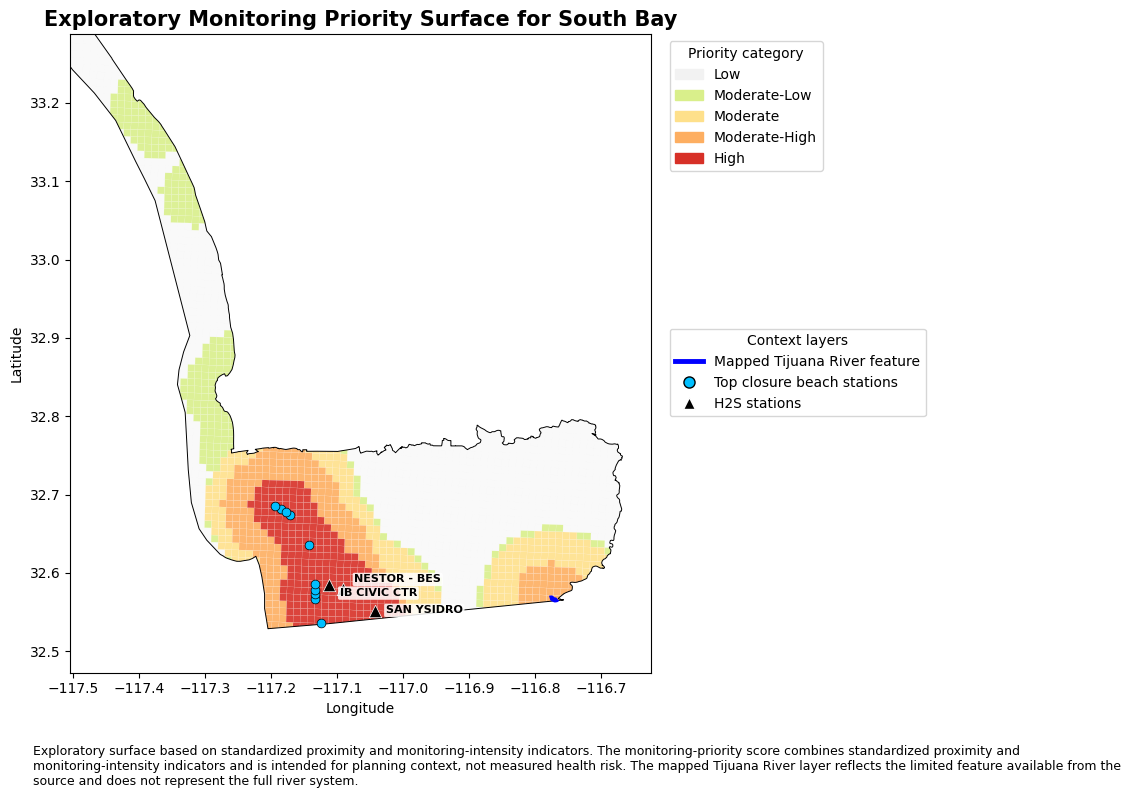

Notebook 12 Cell 9 QA
Grid rows: 1963
H2S station rows: 3
Top closure beach rows: 10
Tijuana River rows: 1
Saved figure: /content/drive/MyDrive/STAT596/Project596_datafiles/figures/figure_11_notebook12_monitoring_priority_surface_final.png
Figure exists: True


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

priority_grid_path = PROCESSED / "notebook12_monitoring_priority_grid.gpkg"
context_points_path = PROCESSED / "notebook12_monitoring_context_points.gpkg"
study_area_boundary_path = PROCESSED / "notebook12_study_area_boundary.gpkg"
river_geometry_path = PROCESSED / "notebook12_tijuana_river_geometry.gpkg"

grid_priority = gpd.read_file(
    priority_grid_path,
    layer="monitoring_priority_grid_epsg3310"
).to_crs("EPSG:4326")

h2s_stations = gpd.read_file(
    context_points_path,
    layer="h2s_stations_epsg3310"
).to_crs("EPSG:4326")

top_beaches = gpd.read_file(
    context_points_path,
    layer="top_closure_beach_stations_epsg3310"
).to_crs("EPSG:4326")

study_area_boundary = gpd.read_file(
    study_area_boundary_path,
    layer="study_area_boundary_epsg3310"
).to_crs("EPSG:4326")

tijuana_river = gpd.read_file(
    river_geometry_path,
    layer="tijuana_river_epsg3310"
).to_crs("EPSG:4326")

category_order = [
    "Low",
    "Moderate-Low",
    "Moderate",
    "Moderate-High",
    "High",
]

category_colors = {
    "Low": "#f2f2f2",
    "Moderate-Low": "#d9ef8b",
    "Moderate": "#fee08b",
    "Moderate-High": "#fdae61",
    "High": "#d73027",
}

grid_priority["priority_category"] = pd.Categorical(
    grid_priority["priority_category"],
    categories=category_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for category in category_order:
    subset = grid_priority[grid_priority["priority_category"] == category]

    if len(subset) > 0:
        alpha_value = 0.45 if category == "Low" else 0.9

        subset.plot(
            ax=ax,
            color=category_colors[category],
            edgecolor="white",
            linewidth=0.08,
            alpha=alpha_value,
            zorder=1
        )

study_area_boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.7,
    zorder=3
)

tijuana_river.plot(
    ax=ax,
    color="blue",
    linewidth=3.5,
    zorder=10
)

top_beaches.plot(
    ax=ax,
    marker="o",
    color="deepskyblue",
    edgecolor="black",
    markersize=40,
    linewidth=0.5,
    zorder=8
)

h2s_stations.plot(
    ax=ax,
    marker="^",
    color="black",
    edgecolor="white",
    markersize=80,
    linewidth=0.5,
    zorder=9
)

if "location_clean" in h2s_stations.columns:
    label_offsets = {
        "NESTOR - BES": (8, 5),
        "SAN YSIDRO": (8, -2),
        "IB CIVIC CTR": (8, -8),
    }

    for _, row in h2s_stations.iterrows():
        label = str(row["location_clean"])
        offset = label_offsets.get(label, (8, 5))

        ax.annotate(
            label,
            xy=(row.geometry.x, row.geometry.y),
            xytext=offset,
            textcoords="offset points",
            fontsize=8,
            weight="bold",
            bbox=dict(
                boxstyle="round,pad=0.15",
                fc="white",
                ec="none",
                alpha=0.85
            ),
            zorder=12
        )

nonzero_cells = grid_priority[grid_priority["monitoring_priority_score"] > 0].copy()

combined_bounds_layers = [
    nonzero_cells,
    h2s_stations,
    top_beaches,
    tijuana_river
]

bounds_gdf = pd.concat(
    [gdf[["geometry"]] for gdf in combined_bounds_layers if len(gdf) > 0],
    ignore_index=True
)

bounds_gdf = gpd.GeoDataFrame(
    bounds_gdf,
    geometry="geometry",
    crs="EPSG:4326"
)

minx, miny, maxx, maxy = bounds_gdf.total_bounds
pad_x = (maxx - minx) * 0.08
pad_y = (maxy - miny) * 0.08

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

priority_handles = [
    mpatches.Patch(
        color=category_colors[category],
        label=category
    )
    for category in category_order
]

context_handles = [
    Line2D(
        [0], [0],
        color="blue",
        linewidth=3.5,
        label="Mapped Tijuana River feature"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="white",
        markerfacecolor="deepskyblue",
        markeredgecolor="black",
        markersize=8,
        label="Top closure beach stations"
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="white",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=9,
        label="H2S stations"
    ),
]

legend1 = ax.legend(
    handles=priority_handles,
    title="Priority category",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=True
)

ax.add_artist(legend1)

ax.legend(
    handles=context_handles,
    title="Context layers",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.55),
    frameon=True
)

ax.set_title(
    "Exploratory Monitoring Priority Surface for South Bay",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

caption = (
    "Exploratory surface based on standardized proximity and monitoring-intensity indicators. "
    "The monitoring-priority score combines standardized proximity and monitoring-intensity "
    "indicators and is intended for planning context, not measured health risk. "
    "The mapped Tijuana River layer reflects the limited feature available from the source "
    "and does not represent the full river system."
)

fig.text(
    0.08,
    0.015,
    caption,
    ha="left",
    fontsize=9,
    wrap=True
)

plt.tight_layout(rect=[0, 0.08, 0.78, 1])

figure_11_path = FIGURES / "figure_11_notebook12_monitoring_priority_surface_final.png"

fig.savefig(
    figure_11_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Grid rows:", len(grid_priority))
print("H2S station rows:", len(h2s_stations))
print("Top closure beach rows:", len(top_beaches))
print("Tijuana River rows:", len(tijuana_river))
print("Saved figure:", figure_11_path)
print("Figure exists:", figure_11_path.exists())

In [ ]:
from pathlib import Path

final_map_name = "figure_11_notebook12_monitoring_priority_surface_final.png"
final_map_path = FIGURES / final_map_name

DRY_RUN = False

if not final_map_path.exists():
    raise FileNotFoundError(f"Final map was not found: {final_map_path}")

map_files = sorted(FIGURES.glob("figure_11_notebook12_monitoring_priority_surface*.png"))

files_to_delete = [
    path for path in map_files
    if path.name != final_map_name
]



print("Final map kept:")
print(final_map_path)

print("\nOlder map versions found:")
for path in files_to_delete:
    print(path.name)

print("\nDelete mode:", "DRY RUN - no files deleted" if DRY_RUN else "DELETE FILES")

if not DRY_RUN:
    for path in files_to_delete:
        path.unlink()

print("\nRemaining Figure 11 map files:")
remaining_files = sorted(FIGURES.glob("figure_11_notebook12_monitoring_priority_surface*.png"))

for path in remaining_files:
    print(path.name)

print("\nFinal map still exists:", final_map_path.exists())

Notebook 12 Figure 11 cleanup
Final map kept:
/content/drive/MyDrive/STAT596/Project596_datafiles/figures/figure_11_notebook12_monitoring_priority_surface_final.png

Older map versions found:

Delete mode: DELETE FILES

Remaining Figure 11 map files:
figure_11_notebook12_monitoring_priority_surface_final.png

Final map still exists: True


In [ ]:
import pandas as pd
from pathlib import Path
from datetime import datetime

outputs = [
    {
        "output_type": "processed_data",
        "file_name": "notebook12_study_area_boundary.gpkg",
        "folder": PROCESSED,
        "paper_role": "Study area boundary used to clip the 1 km grid",
        "recommended_for_final_paper": "No",
        "description": "Boundary layer created from South Bay census tract geometry."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_base_1km_grid.gpkg",
        "folder": PROCESSED,
        "paper_role": "Intermediate base grid",
        "recommended_for_final_paper": "No",
        "description": "Initial 1 km grid clipped to the study area before removing tiny sliver cells."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_clean_1km_grid.gpkg",
        "folder": PROCESSED,
        "paper_role": "Clean raster-style grid foundation",
        "recommended_for_final_paper": "Maybe",
        "description": "Clean 1 km grid used as the base spatial unit for the monitoring-priority surface."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_monitoring_context_points.gpkg",
        "folder": PROCESSED,
        "paper_role": "Monitoring station context layer",
        "recommended_for_final_paper": "Maybe",
        "description": "Beach monitoring station and H2S station point layers used in grid scoring and mapping."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_tijuana_river_geometry.gpkg",
        "folder": PROCESSED,
        "paper_role": "Mapped Tijuana River feature",
        "recommended_for_final_paper": "Maybe",
        "description": "Limited Tijuana River line feature extracted from the ArcGIS river service."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_grid_distance_variables.gpkg",
        "folder": PROCESSED,
        "paper_role": "Grid distance variables",
        "recommended_for_final_paper": "No",
        "description": "Grid cells with distance to H2S stations, beach stations, impacted beaches, top closure beaches, and mapped Tijuana River feature."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_grid_intensity_variables.gpkg",
        "folder": PROCESSED,
        "paper_role": "Grid intensity variables",
        "recommended_for_final_paper": "No",
        "description": "Grid cells with nearby monitoring intensity measures within 5 km."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_grid_scored_unclassified.gpkg",
        "folder": PROCESSED,
        "paper_role": "Unclassified monitoring priority score",
        "recommended_for_final_paper": "No",
        "description": "Grid cells with standardized component scores and continuous monitoring-priority score."
    },
    {
        "output_type": "processed_data",
        "file_name": "notebook12_monitoring_priority_grid.gpkg",
        "folder": PROCESSED,
        "paper_role": "Final monitoring priority grid",
        "recommended_for_final_paper": "Yes",
        "description": "Final classified grid layer used to create the exploratory monitoring-priority surface."
    },
    {
        "output_type": "table",
        "file_name": "notebook12_initial_input_inventory.csv",
        "folder": TABLES,
        "paper_role": "Input QA inventory",
        "recommended_for_final_paper": "No",
        "description": "Documents input files available at the beginning of Notebook 12."
    },
    {
        "output_type": "table",
        "file_name": "notebook12_distance_variable_summary.csv",
        "folder": TABLES,
        "paper_role": "Distance variable QA",
        "recommended_for_final_paper": "Maybe",
        "description": "Summary statistics for grid-cell distance variables."
    },
    {
        "output_type": "table",
        "file_name": "notebook12_intensity_variable_summary.csv",
        "folder": TABLES,
        "paper_role": "Intensity variable QA",
        "recommended_for_final_paper": "Maybe",
        "description": "Summary statistics for nearby monitoring-intensity variables."
    },
    {
        "output_type": "table",
        "file_name": "notebook12_priority_component_summary.csv",
        "folder": TABLES,
        "paper_role": "Priority score methodology table",
        "recommended_for_final_paper": "Yes",
        "description": "Documents each standardized score component, source variable, method, weight, and nonzero-cell count."
    },
    {
        "output_type": "table",
        "file_name": "notebook12_score_summary.csv",
        "folder": TABLES,
        "paper_role": "Score summary table",
        "recommended_for_final_paper": "Maybe",
        "description": "Summary statistics for each component score and the final monitoring-priority score."
    },
    {
        "output_type": "table",
        "file_name": "notebook12_monitoring_priority_grid_summary.csv",
        "folder": TABLES,
        "paper_role": "Priority category summary table",
        "recommended_for_final_paper": "Yes",
        "description": "Summarizes grid-cell counts, area, and score ranges by priority category."
    },
    {
        "output_type": "table",
        "file_name": "notebook12_top_monitoring_priority_cells.csv",
        "folder": TABLES,
        "paper_role": "Top priority cells table",
        "recommended_for_final_paper": "Yes",
        "description": "Lists the highest-scoring grid cells and the component variables contributing to their scores."
    },
    {
        "output_type": "figure",
        "file_name": "figure_11_notebook12_monitoring_priority_surface_final.png",
        "folder": FIGURES,
        "paper_role": "Final monitoring priority surface map",
        "recommended_for_final_paper": "Yes",
        "description": "Final paper-ready map showing the exploratory 1 km monitoring-priority surface."
    },
]

records = []

for item in outputs:
    file_path = item["folder"] / item["file_name"]
    exists = file_path.exists()

    if exists:
        file_size_kb = round(file_path.stat().st_size / 1024, 2)
        modified_time = datetime.fromtimestamp(file_path.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S")
    else:
        file_size_kb = None
        modified_time = None

    records.append({
        "output_type": item["output_type"],
        "file_name": item["file_name"],
        "file_path": str(file_path),
        "exists": exists,
        "file_size_kb": file_size_kb,
        "modified_time": modified_time,
        "paper_role": item["paper_role"],
        "recommended_for_final_paper": item["recommended_for_final_paper"],
        "description": item["description"],
    })

output_inventory = pd.DataFrame(records)

inventory_path = TABLES / "notebook12_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)


print("Expected outputs:", len(output_inventory))
print("Found outputs:", output_inventory["exists"].sum())
print("Missing outputs:", (~output_inventory["exists"]).sum())
print("Saved inventory:", inventory_path)
print("Inventory file exists:", inventory_path.exists())

display(output_inventory)

missing_outputs = output_inventory[~output_inventory["exists"]]

print("\nMissing outputs, if any:")
if len(missing_outputs) == 0:
    print("No missing expected outputs.")
else:
    display(missing_outputs)

Notebook 12 output inventory QA
Expected outputs: 17
Found outputs: 17
Missing outputs: 0
Saved inventory: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_output_inventory.csv
Inventory file exists: True


,output_type,file_name,file_path,exists,file_size_kb,modified_time,paper_role,recommended_for_final_paper,description
0,processed_data,notebook12_study_area_boundary.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,160.00,2026-05-04 21:08:06,Study area boundary used to clip the 1 km grid,No,Boundary layer created from South Bay census t...
1,processed_data,notebook12_base_1km_grid.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,712.00,2026-05-04 21:09:11,Intermediate base grid,No,Initial 1 km grid clipped to the study area be...
2,processed_data,notebook12_clean_1km_grid.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,700.00,2026-05-04 21:10:33,Clean raster-style grid foundation,Maybe,Clean 1 km grid used as the base spatial unit ...
3,processed_data,notebook12_monitoring_context_points.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,172.00,2026-05-04 21:11:47,Monitoring station context layer,Maybe,Beach monitoring station and H2S station point...
4,processed_data,notebook12_tijuana_river_geometry.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,96.00,2026-05-04 21:41:08,Mapped Tijuana River feature,Maybe,Limited Tijuana River line feature extracted f...
5,processed_data,notebook12_grid_distance_variables.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,788.00,2026-05-04 21:41:09,Grid distance variables,No,"Grid cells with distance to H2S stations, beac..."
6,processed_data,notebook12_grid_intensity_variables.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,820.00,2026-05-04 21:42:31,Grid intensity variables,No,Grid cells with nearby monitoring intensity me...
7,processed_data,notebook12_grid_scored_unclassified.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,864.00,2026-05-04 21:45:47,Unclassified monitoring priority score,No,Grid cells with standardized component scores ...
8,processed_data,notebook12_monitoring_priority_grid.gpkg,/content/drive/MyDrive/STAT596/Project596_data...,True,880.00,2026-05-04 21:47:24,Final monitoring priority grid,Yes,Final classified grid layer used to create the...
9,table,notebook12_initial_input_inventory.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,1.74,2026-05-04 21:05:03,Input QA inventory,No,Documents input files available at the beginni...



Missing outputs, if any:
No missing expected outputs.


In [ ]:
import pandas as pd
from pathlib import Path
from datetime import datetime

caption_records = [
    {
        "figure_or_table_id": "Figure 11",
        "output_type": "figure",
        "file_name": "figure_11_notebook12_monitoring_priority_surface_final.png",
        "folder": FIGURES,
        "paper_section": "Results",
        "recommended_for_final_paper": "Yes",
        "caption": (
            "Exploratory 1 km monitoring-priority surface for South Bay. "
            "The map classifies grid cells from low to high priority based on standardized "
            "proximity and monitoring-intensity indicators, including proximity to H2S stations, "
            "impacted beach monitoring stations, top closure beach stations, nearby closure intensity, "
            "nearby H2S severity, and distance to the mapped Tijuana River feature."
        ),
        "interpretation_for_paper": (
            "The highest-priority grid cells are concentrated in the South Bay coastal corridor, "
            "especially near Imperial Beach and nearby H2S monitoring locations. These areas appear "
            "to combine elevated beach closure intensity with stronger proximity to H2S and beach "
            "monitoring indicators, making them important candidates for continued monitoring, alerts, "
            "cleanup planning, and public-health resource planning."
        ),
        "limitation_note": (
            "The monitoring-priority score is exploratory and planning-oriented. It does not represent "
            "measured health risk, causal exposure, or a predictive model. The mapped Tijuana River layer "
            "reflects the limited feature available from the source and does not represent the full river system."
        )
    },
    {
        "figure_or_table_id": "Table 11",
        "output_type": "table",
        "file_name": "notebook12_priority_component_summary.csv",
        "folder": TABLES,
        "paper_section": "Methodology or Results",
        "recommended_for_final_paper": "Yes",
        "caption": (
            "Standardized monitoring-priority score components used to construct the 1 km grid surface."
        ),
        "interpretation_for_paper": (
            "This table documents the six equal-weight components used in the final priority score: "
            "H2S proximity, river proximity, impacted beach proximity, top-closure beach proximity, "
            "beach closure intensity, and H2S severity. The table helps make the scoring process transparent."
        ),
        "limitation_note": (
            "The weighting scheme is intentionally simple and exploratory. Equal weights were used for "
            "interpretability rather than because the variables have proven equal causal importance."
        )
    },
    {
        "figure_or_table_id": "Table 12",
        "output_type": "table",
        "file_name": "notebook12_monitoring_priority_grid_summary.csv",
        "folder": TABLES,
        "paper_section": "Results",
        "recommended_for_final_paper": "Yes",
        "caption": (
            "Summary of grid cells and area by monitoring-priority category."
        ),
        "interpretation_for_paper": (
            "This table shows how the study area was divided across low, moderate-low, moderate, "
            "moderate-high, and high priority classes. Low-priority cells represent grid cells with no "
            "nonzero score, while the remaining nonzero cells were divided into priority categories "
            "based on their score distribution."
        ),
        "limitation_note": (
            "Priority categories are relative to this study area and dataset combination. They should "
            "not be interpreted as regulatory thresholds."
        )
    },
    {
        "figure_or_table_id": "Table 13",
        "output_type": "table",
        "file_name": "notebook12_top_monitoring_priority_cells.csv",
        "folder": TABLES,
        "paper_section": "Results or Appendix",
        "recommended_for_final_paper": "Yes",
        "caption": (
            "Top 25 grid cells with the highest exploratory monitoring-priority scores."
        ),
        "interpretation_for_paper": (
            "The highest-scoring cells provide a focused list of locations where multiple indicators "
            "overlap most strongly. This table supports the applied question of which areas may need "
            "additional monitoring attention or planning review."
        ),
        "limitation_note": (
            "These are ranked planning indicators, not confirmed exposure locations. The table should "
            "be interpreted alongside the map and the component-score methodology."
        )
    },
]

caption_helper = pd.DataFrame(caption_records)

caption_helper["file_path"] = caption_helper.apply(
    lambda row: str(row["folder"] / row["file_name"]),
    axis=1
)

caption_helper["exists"] = caption_helper["file_path"].apply(
    lambda path: Path(path).exists()
)

caption_helper["modified_time"] = caption_helper["file_path"].apply(
    lambda path: (
        datetime.fromtimestamp(Path(path).stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S")
        if Path(path).exists()
        else None
    )
)

caption_helper = caption_helper[
    [
        "figure_or_table_id",
        "output_type",
        "file_name",
        "file_path",
        "exists",
        "modified_time",
        "paper_section",
        "recommended_for_final_paper",
        "caption",
        "interpretation_for_paper",
        "limitation_note",
    ]
]

caption_helper_path = TABLES / "notebook12_final_figure_caption_helper.csv"
caption_helper.to_csv(caption_helper_path, index=False)


print("Caption/helper records:", len(caption_helper))
print("Files found:", caption_helper["exists"].sum())
print("Missing files:", (~caption_helper["exists"]).sum())
print("Saved caption helper:", caption_helper_path)
print("Caption helper file exists:", caption_helper_path.exists())

display(caption_helper)

missing_caption_files = caption_helper[~caption_helper["exists"]]

print("\nMissing caption/helper files, if any:")
if len(missing_caption_files) == 0:
    print("No missing caption/helper files.")
else:
    display(missing_caption_files)

Notebook 12 caption helper QA
Caption/helper records: 4
Files found: 4
Missing files: 0
Saved caption helper: /content/drive/MyDrive/STAT596/Project596_datafiles/tables/notebook12_final_figure_caption_helper.csv
Caption helper file exists: True


,figure_or_table_id,output_type,file_name,file_path,exists,modified_time,paper_section,recommended_for_final_paper,caption,interpretation_for_paper,limitation_note
0,Figure 11,figure,figure_11_notebook12_monitoring_priority_surfa...,/content/drive/MyDrive/STAT596/Project596_data...,True,2026-05-04 22:01:04,Results,Yes,Exploratory 1 km monitoring-priority surface f...,The highest-priority grid cells are concentrat...,The monitoring-priority score is exploratory a...
1,Table 11,table,notebook12_priority_component_summary.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,2026-05-04 21:45:47,Methodology or Results,Yes,Standardized monitoring-priority score compone...,This table documents the six equal-weight comp...,The weighting scheme is intentionally simple a...
2,Table 12,table,notebook12_monitoring_priority_grid_summary.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,2026-05-04 21:47:24,Results,Yes,Summary of grid cells and area by monitoring-p...,This table shows how the study area was divide...,Priority categories are relative to this study...
3,Table 13,table,notebook12_top_monitoring_priority_cells.csv,/content/drive/MyDrive/STAT596/Project596_data...,True,2026-05-04 21:47:24,Results or Appendix,Yes,Top 25 grid cells with the highest exploratory...,The highest-scoring cells provide a focused li...,"These are ranked planning indicators, not conf..."



Missing caption/helper files, if any:
No missing caption/helper files.
